# Figure 1c — fit/convergence yield vs. end-to-end recovery yield across read noise x peak QE

*Ported from the `developer`-branch dev notebook `Figure1_maximum_readnoise.ipynb`.*

For a single, isolated emitter already centred in a 2x2-Bayer-unit-cell ROI, bootstrap fits
are run across a 2-D grid of read noise (RMS e-) and peak per-pixel QE, for three real dyes
(ATTO 488, ATTO 565, ATTO 647N). Each bootstrap draws a fresh position (+/-1 px of ROI centre),
photon count, and noise realisation, then re-fits from scratch.

**`FAST_MODE` flag (below):** `True` (default) runs a small, fast grid (few read-noise/QE
points, a few hundred bootstraps) that reproduces the same trend and lets old vs. new criteria
be compared directly in minutes. `FAST_MODE = False` reproduces the full published sweep (100
read-noise points x 60 QE points x 3 dyes x 20,000 bootstraps each) — this is genuinely
hours-to-days of compute; run it only once the FAST_MODE comparison below has been reviewed.

In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [2]:
import time
import types
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Bare `pyS3M.X` imports (not `from src.X import ...`): AnalysisPipeline/SR_Functions add
# `src/` to `sys.path` and bare-import internally, so importing via the `pyS3M.` package path
# keeps every Enum/dataclass identity (e.g. FittingStrategy) consistent with what the fitting
# pipeline itself constructs -- see notebooks/figures/SI/FigureSI_EmitterDensityTests.ipynb.
from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, PlottingBase, sCMOSFunctions
from pyS3M.simulation.multicolour import (
    MultiC_Sim_Funcs, FittingStrategy, SimulationConfig,
)

IO = IOFunctions.IO_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
sCMOS = sCMOSFunctions.sCMOS_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter(dark_background=False)

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/figures -> repo root
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
OUT_ROOT = Path("outputs") / "Figure_1c"  # git-ignored (bare `outputs/` rule in .gitignore)

numexpr.utils — INFO — Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.


numexpr.utils — INFO — NumExpr defaulting to 16 threads.


pyS3M.Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/logs/pyS3M.Constants_20260914_164400.log


## Sweep size: `FAST_MODE` vs. the full published grid

In [3]:
FAST_MODE = False  # False -> the real, hours-to-days-long full sweep this figure was published with

dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']
n_photons = 1000

if FAST_MODE:
    n_bootstrap = 300
    read_noise_space = np.logspace(np.log10(0.1), np.log10(10.0), 6)
    peak_qy_space = np.linspace(0.0, 1.0, 6)
else:
    n_bootstrap = 20000
    read_noise_space = np.logspace(np.log10(0.1), np.log10(10.0), 100)
    peak_qy_space = np.linspace(0.0, 1.0, 60)

n_photon_space = np.array([n_photons], dtype=float)

# Ground-truth position within POS_ERR_MULTIPLIER x the fit's own reported error is the new
# success criterion, so no bootstrap-position ROI-bounds check is needed to define "success"
# any more -- but the ROI size is still needed to size the simulated image.
# `test_simulation_method_2d_sweep` resizes to `n_unit_cells` x the camera's 2x2 Bayer unit
# cell when a `mosaic_unit` is set (it is, below), overriding any requested image_size
# directly -- so the ROI size used everywhere else is derived the same way, not hardcoded, to
# avoid the two silently diverging.
n_unit_cells = 7
pixel_size = 69  # nm (Ximea)

sweep_tag = "fast" if FAST_MODE else "full"
save_folder = OUT_ROOT / sweep_tag
save_folder.mkdir(parents=True, exist_ok=True)

print(f"FAST_MODE={FAST_MODE}  n_bootstrap={n_bootstrap}")
print(f"read_noise: {read_noise_space[0]:.4f}-{read_noise_space[-1]:.2f} RMS e-  ({len(read_noise_space)} pts)")
print(f"peak_qy:    {peak_qy_space[0]:.2f}-{peak_qy_space[-1]:.2f}  ({len(peak_qy_space)} pts)")
print(f"Total fits: {len(dyes) * len(read_noise_space) * len(peak_qy_space) * n_bootstrap:,}")
print(f"Saving to:  {save_folder}")

FAST_MODE=False  n_bootstrap=20000
read_noise: 0.1000-10.00 RMS e-  (100 pts)
peak_qy:    0.00-1.00  (60 pts)
Total fits: 360,000,000
Saving to:  outputs/Figure_1c/full


## Camera calibration & spectral setup

In [4]:
gain = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
rqe = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))

gain_median = float(np.median(gain))
offset_median = float(np.median(offset))
rqe_median = float(np.median(rqe))

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])  # B=0, G=1, R=2
base_pixel_QYs = pixel_QYs / np.max(pixel_QYs)  # normalised to peak=1; sweep rescales by peak_qy

masks = M_F.get_masks(size_x=2 * n_unit_cells, size_y=2 * n_unit_cells)
filters = []

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {'sigma': 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = 'image'

print(f"gain={gain_median:.3f}  offset={offset_median:.3f}  rqe={rqe_median:.4f}")
print(f"base_pixel_QYs peak: {np.max(base_pixel_QYs):.4f} (should be 1.0)")

gain=0.414  offset=32.346  rqe=1.0000
base_pixel_QYs peak: 1.0000 (should be 1.0)


In [5]:
camera_parameters_base = {
    'gain':                np.full((2 * n_unit_cells, 2 * n_unit_cells), gain_median),
    'offset':              np.full((2 * n_unit_cells, 2 * n_unit_cells), offset_median),
    'variance':            np.full((2 * n_unit_cells, 2 * n_unit_cells), 1.0),   # placeholder, overridden per rn
    'readnoise':           1.0,                                                    # placeholder, overridden per rn
    'rqe':                 np.full((2 * n_unit_cells, 2 * n_unit_cells), rqe_median),
    'masks':               masks,
    'pixel_QYs':           base_pixel_QYs,
    'pixel_order':         ['B', 'G', 'R'],
    'pixel_order_indices': {'B': 0, 'G': 1, 'R': 2},
    'mosaic_unit':         M_F.mosaic_unit,
}

config = SimulationConfig(
    n_bootstrap=n_bootstrap,
    background_photons=5.0,
    background_colour=[1, 1, 1],
    NA=1.49,
    pixel_size=pixel_size,
    cpu_fraction=0.9,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    use_stochastic_photons=True,
    save_summary_csvs=False,
    verbose=False,
    n_unit_cells=n_unit_cells,
)

roi_size = n_unit_cells * M_F.mosaic_unit.shape[0]
print(f"Simulated ROI size actually used by test_simulation_method_2d_sweep: {roi_size}x{roi_size} px")

Simulated ROI size actually used by test_simulation_method_2d_sweep: 14x14 px


## Run the 2-D sweep

Factorised across (n_photon, peak_qy): the photoelectron batch is generated once per (n_photon, peak_qy) pair and reused across every read-noise value in the inner loop (Poisson thinning across the QY axis), so this is far cheaper than a naive triple loop.

In [6]:
start = time.time()
for dye in dyes:
    MSF.test_simulation_method_2d_sweep(
        dye=dye,
        filters=filters,
        wavelength=wavelength,
        camera_parameters=camera_parameters_base,
        save_folder=str(save_folder),
        n_photon_space=n_photon_space,
        smoothing_function=smoothing_function,
        strategy=FittingStrategy.STANDARD_DATA,
        read_noise_space=read_noise_space,
        peak_qy_space=peak_qy_space,
        config=config,
        overwrite=False,  # resume-safe: re-running this cell skips combinations already on disk
    )

print(f"\nAll grid points complete in {(time.time() - start) / 60.0:.2f} min.")

pyS3M.simulation.multicolour — INFO — 
[ATTO 488] 2-D sweep complete: 6000 combinations  total time 0.191 min


pyS3M.simulation.multicolour — INFO — 
[ATTO 565] 2-D sweep complete: 6000 combinations  total time 0.177 min


pyS3M.simulation.multicolour — INFO — 
[ATTO 647N] 2-D sweep complete: 6000 combinations  total time 0.174 min



All grid points complete in 0.55 min.


## Fit-yield metrics: convergence vs. end-to-end recovery

For every `(dye, peak_qy, read_noise)` grid cell:

- `yield_convergence` — the original metric: fraction of bootstraps where the LM fit returned
  a finite `xc`/`yc` at all. No accuracy requirement.
- `yield_recovery_pos` — fraction where, additionally, the ground-truth position lies within
  `POS_ERR_MULTIPLIER` x the fit's own reported localisation error (`xc_err`/`yc_err`) — the
  headline "more stringent" fit-yield metric.
- `yield_recovery_pos_colour` — `yield_recovery_pos`, further requiring the fitted spectral
  fingerprint (`A_B`/`A_G`/`A_R`) within `COLOUR_ERR_MULTIPLIER` x its own fitted error of the
  dye's *actual per-bootstrap realised* fingerprint (`{dye}_nphot_{n}_true_colour_fractions.csv`,
  saved by `test_simulation_method_2d_sweep` from the same stochastic photon draw that generated
  that bootstrap's image) rather than the single population-average fingerprint -- these differ
  bootstrap-to-bootstrap because of finite-photon colour-sampling noise (see the notebook's own
  low-read-noise discussion). Falls back to the population average for older raw results computed
  before this was saved.
- `yield_recovery_sigma` — fraction where the ground-truth position lies within one fitted PSF
  sigma (`s_x`/`s_y`) instead of the localisation error — kept for reference/comparison only.

`sigma_xy_surf`/`colour_std_surf` (fit precision, unchanged from the dev notebook) are kept
for reference, computed on the `yield_recovery_pos` population.

In [7]:
POS_ERR_MULTIPLIER = 3.0     # x xc_err/yc_err -- conventional "3-sigma" bar, ~99.7% per-axis coverage for a calibrated fit
COLOUR_ERR_MULTIPLIER = 3.0  # x A_*_err, same rationale, applied to the optional colour layer

n_qy, n_rn = len(peak_qy_space), len(read_noise_space)
yield_kinds = ['convergence', 'recovery_pos', 'recovery_pos_colour', 'recovery_sigma']

yield_surf = {dye: {k: np.full((n_qy, n_rn), np.nan) for k in yield_kinds} for dye in dyes}
sigma_xy_surf = {dye: np.full((n_qy, n_rn), np.nan) for dye in dyes}
colour_std_surf = {dye: np.full((n_qy, n_rn), np.nan) for dye in dyes}
n_fits_surf = {dye: np.full((n_qy, n_rn), np.nan) for dye in dyes}

for dye in dyes:
    dyestr = dye.replace(' ', '-').replace('/', '-')

    # Per-bootstrap true colour fraction (the actual finite-photon-sampling colour draw,
    # saved once per (dye, n_photon) at qy_max -- see test_simulation_method_2d_sweep),
    # not the single population-average fingerprint. Falls back to the population
    # average for combinations computed before this was saved -- re-run the sweep cell
    # above to backfill (cheap: existing per-(qy,rn) raw results are still skipped).
    true_colour_path = save_folder / f'{dye}_nphot_{n_photons:.0f}_true_colour_fractions.csv'
    true_colour = pd.read_csv(true_colour_path).to_numpy() if true_colour_path.exists() else None
    if true_colour is None:
        print(f'  [{dye}] no true_colour_fractions.csv yet -- falling back to population-average fingerprint')

    for i, peak_qy in enumerate(peak_qy_space):
        for j, rn in enumerate(read_noise_space):
            flag = f'{dyestr}_qy_{peak_qy:.3f}_readnoise_{rn:.6f}_'

            gt_path = save_folder / f'{flag}LM_method_{dye}_fittesting_input_groundtruthpositions.csv'
            raw_path = save_folder / f'{flag}LM_method_{dye}_rawresults.h5'
            inp_path = save_folder / f'{flag}LM_method_{dye}_fittesting_input_parameters.csv'

            if not (gt_path.exists() and raw_path.exists() and inp_path.exists()):
                continue

            gt = pd.read_csv(gt_path)
            results = pd.read_hdf(raw_path)
            inp = pd.read_csv(inp_path).to_numpy()[0]
            results = results[results['photon_level'] == 0]
            n_fits_surf[dye][i, j] = len(results)

            x0 = gt['x0'].to_numpy() / pixel_size
            y0 = gt['y0'].to_numpy() / pixel_size

            converged = ~(results['xc'].isna() | results['yc'].isna())
            yield_surf[dye]['convergence'][i, j] = converged.mean()

            err_x = np.abs(results['xc'].to_numpy() - x0)
            err_y = np.abs(results['yc'].to_numpy() - y0)

            recovered_pos = (
                converged
                & (err_x < POS_ERR_MULTIPLIER * results['xc_err'].to_numpy())
                & (err_y < POS_ERR_MULTIPLIER * results['yc_err'].to_numpy())
            )
            recovered_sigma = converged & (err_x < results['s_x'].to_numpy()) & (err_y < results['s_y'].to_numpy())
            yield_surf[dye]['recovery_pos'][i, j] = recovered_pos.mean()
            yield_surf[dye]['recovery_sigma'][i, j] = recovered_sigma.mean()

            dye_BGR = inp[-3:]
            dye_BGR = dye_BGR / np.sum(dye_BGR)
            if true_colour is not None and len(true_colour) == len(results):
                true_frac_b = true_colour  # (n_bootstrap, 3) -- per-bootstrap ground truth, B/G/R
            else:
                true_frac_b = np.tile(dye_BGR, (len(results), 1))
            colour_ok = np.ones(len(results), dtype=bool)
            for c, lbl in enumerate(['A_B', 'A_G', 'A_R']):
                colour_ok &= np.abs(results[lbl].to_numpy() - true_frac_b[:, c]) < COLOUR_ERR_MULTIPLIER * results[f'{lbl}_err'].to_numpy()
            yield_surf[dye]['recovery_pos_colour'][i, j] = (recovered_pos & colour_ok).mean()

            filt = recovered_pos & (results['s_x'].to_numpy() > 0) & (results['s_y'].to_numpy() > 0)
            if filt.sum() > 10:
                sigma_xy_surf[dye][i, j] = (
                    np.sqrt((np.nanstd(err_x[filt]) ** 2 + np.nanstd(err_y[filt]) ** 2) / 2) * pixel_size
                )
                colour_loc = true_frac_b[filt]  # per-bootstrap true fingerprint, not population mean
                colour = np.vstack([
                    results['A_B'].to_numpy()[filt], results['A_G'].to_numpy()[filt], results['A_R'].to_numpy()[filt],
                ]).T
                colour_std_surf[dye][i, j] = np.nanstd(np.linalg.norm(colour - colour_loc, axis=1))

    print(
        f"{dye}: convergence {np.nanmin(yield_surf[dye]['convergence']):.3f}-{np.nanmax(yield_surf[dye]['convergence']):.3f}"
        f"  recovery_pos {np.nanmin(yield_surf[dye]['recovery_pos']):.3f}-{np.nanmax(yield_surf[dye]['recovery_pos']):.3f}"
        f"  recovery_pos_colour {np.nanmin(yield_surf[dye]['recovery_pos_colour']):.3f}-{np.nanmax(yield_surf[dye]['recovery_pos_colour']):.3f}"
        f"  recovery_sigma {np.nanmin(yield_surf[dye]['recovery_sigma']):.3f}-{np.nanmax(yield_surf[dye]['recovery_sigma']):.3f}"
    )

print('Done.')

ATTO 488: convergence 0.093-1.000  recovery_pos 0.074-0.997  recovery_pos_colour 0.067-0.977  recovery_sigma 0.038-1.000


ATTO 565: convergence 0.093-0.995  recovery_pos 0.074-0.961  recovery_pos_colour 0.074-0.912  recovery_sigma 0.039-0.995


ATTO 647N: convergence 0.093-1.000  recovery_pos 0.076-0.975  recovery_pos_colour 0.075-0.944  recovery_sigma 0.040-1.000
Done.


## Real camera survey overlay

`Camera_History.ods` is a hand-curated literature/vendor survey of read noise (RMS e-) and peak QE for sCMOS/CMOS cameras, released 2018 onward, compiled for this figure (Model/Year/RMS/PeakQY/Company/Pixelsize columns). Overlaid as white dots on every surface below so the simulated grid can be read directly against where real hardware actually sits.

In [8]:
camera_data = pd.read_excel("Camera_History.ods")
camera_data = camera_data[camera_data['Year'] >= 2018]
print(f"{len(camera_data)} cameras (2018+) loaded for overlay")
camera_data[['Model', 'Year', 'RMS', 'PeakQY', 'Company']]

7 cameras (2018+) loaded for overlay


,Model,Year,RMS,PeakQY,Company
13,MU051CG-SY,2019,2.34,0.67,Ximea
14,CS165CU,2020,4.00,0.65,Thorlabs
15,CS126CU,2020,2.50,0.65,Thorlabs
16,ASI676MC,2024,0.56,0.83,ZWO
17,ASI585MC,2022,0.70,0.91,ZWO
18,ASI183MC,2021,1.60,0.84,ZWO
19,CS505CU,2018,1.94,0.65,Thorlabs


## Figure: fit-yield 2-D surfaces, convergence vs. recovery (+/- colour gate)

Top row: the original convergence-only metric. Second row: the headline recovery-yield
metric (`POS_ERR_MULTIPLIER` x localisation error). Third row: recovery yield with the
spectral-fingerprint gate added. Columns are the three dyes. The 80% contour is drawn as a
heuristic benchmark line, not a derived accuracy threshold (see note above).

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/PlottingBase.py:487: UserWarning: Width 6.75" exceeds two-column standard (6.69")
  warnings.warn(


/tmp/ipykernel_1907157/2038080829.py:50: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  plt.savefig('Fig_1c.svg', dpi=600, format='svg')


/home/jbeckwith/.virtualenvs/pyS3M/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig.canvas.print_figure(bytes_io, **kw)


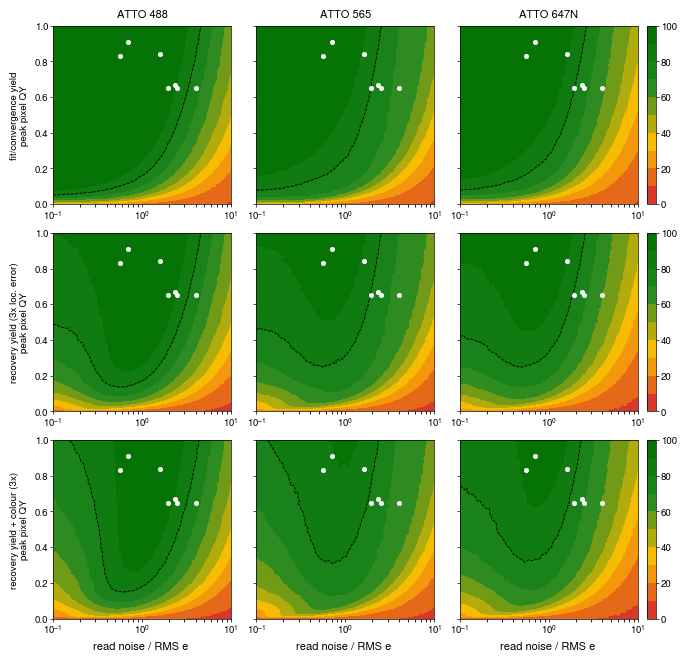

In [9]:
cmap_yield = LinearSegmentedColormap.from_list('gar', ['#D2222D', '#FFBF00', '#238823', '#007000'])
fill_levels = np.linspace(0, 100, 11)

row_kinds = ['convergence', 'recovery_pos', 'recovery_pos_colour']
row_labels = ['fit/convergence yield', f'recovery yield ({POS_ERR_MULTIPLIER:.0f}x loc. error)',
              f'recovery yield + colour ({COLOUR_ERR_MULTIPLIER:.0f}x)']

fig, axs = plotter.two_column_plot(nrows=len(row_kinds), ncols=len(dyes), width=6.75, height=6.5)

for row, (kind, label) in enumerate(zip(row_kinds, row_labels)):
    for col, dye in enumerate(dyes):
        ax = axs[row, col]
        data = yield_surf[dye][kind] * 100
        image = ax.contourf(
            read_noise_space, peak_qy_space, data,
            levels=fill_levels, cmap=cmap_yield, vmin=0, vmax=100, antialiased=False,
        )
        ax.contour(read_noise_space, peak_qy_space, data, levels=[80], colors='k', linewidths=0.6, linestyles='--')
        ax.set_xscale('log')
        ax.grid(False)
        ax.set_xlim([read_noise_space[0], read_noise_space[-1]])
        ax.set_ylim([0.0, 1])
        ax.tick_params(labelsize=7)
        if row == len(row_kinds) - 1:
            ax.set_xlabel('read noise / RMS e⁻', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'{label}\npeak pixel QY', fontsize=7)
        else:
            ax.set_yticklabels('')
        if row == 0:
            ax.set_title(dye, fontsize=8)
        if col == len(dyes) - 1:
            cbar = plt.colorbar(image, ax=ax, pad=0.01, cmap=cmap_yield)
            cbar.set_ticks([0, 20, 40, 60, 80, 100])
        # SVG-only artefact: contourf bands paint no edge by default, so
        # antialiased=False alone still leaves a thin seam between adjacent bands in
        # vector output (invisible in matplotlib's own PNG export, but real in an SVG
        # viewer -- confirmed by rasterising with Inkscape's renderer). Painting each
        # band's edge in its own fill colour closes the seam; a generic
        # `for c in ax.collections: c.set_linewidth(0.1)` also touches the 80% contour
        # line above (it lives in ax.collections too), flattening its width --
        # targeting `image` specifically avoids that.
        image.set_edgecolor('face')
        image.set_linewidth(0.3)
        ax.scatter(
            camera_data['RMS'], camera_data['PeakQY'],
            s=10, lw=0.5, facecolor='white', edgecolors='white', zorder=5,
        )

plt.savefig('Fig_1c.svg', dpi=600, format='svg')
plt.show()

## Is the low-read-noise dip real, or an artefact of the reported-error estimator?

At fixed peak QY, `yield_recovery_pos` rises with read noise before saturating -- the best
(lowest-noise) cameras look *worse* than moderately noisy ones. `xc_err`/`yc_err`/`A_*_err`
come from `scipy.optimize.leastsq`'s covariance matrix: a proper joint fit over
position+colour+background, but a *local, single-realisation* estimate -- "if this same
underlying signal were re-measured with different pixel noise, how much would the fit move."
It has no way to see that the underlying signal itself varies bootstrap-to-bootstrap, because
each bootstrap draws its own finite ~1000-photon spectral sample
(`generate_bootstrap_colour_ratios`, saved per-bootstrap in `*_true_colour_fractions.csv`).
That sampling variance doesn't shrink with read noise, so once read noise drops below it,
the reported errors keep shrinking straight past the true floor and start under-covering it.

**Quick diagnostic fix, applied only below (the cells above are untouched):** for each
`(dye, peak_qy)` column, take that column's own lowest-read-noise cell -- where pixel noise
is smallest, so only the sampling-noise floor remains in the real bootstrap-to-bootstrap
scatter -- and measure that floor directly from the already-computed ground truth. Add it in
quadrature to `xc_err`/`yc_err`/`A_*_err` everywhere in that column, then re-apply the same
`POS_ERR_MULTIPLIER`/`COLOUR_ERR_MULTIPLIER` x error test used above. This loads only the
already-finished sweep on disk -- no new simulation.

**Caveat to keep in view:** the floor is measured from the same ground truth the criterion is
tested against, so this is a documented, quantified correction for a known estimator blind
spot -- not a claim that `xc_err`/`A_*_err` were recomputed at the source. The "not quick"
version of this fix would add a colour-sampling nuisance term to the covariance calculation
itself, in `ImageAnalysisFunctions.py`/`gaussoptfuncs.py`.

In [10]:
yield_surf_floorcorr = {
    dye: {'recovery_pos': np.full((n_qy, n_rn), np.nan), 'recovery_pos_colour': np.full((n_qy, n_rn), np.nan)}
    for dye in dyes
}

for dye in dyes:
    dyestr = dye.replace(' ', '-').replace('/', '-')
    true_colour_path = save_folder / f'{dye}_nphot_{n_photons:.0f}_true_colour_fractions.csv'
    true_colour = pd.read_csv(true_colour_path).to_numpy() if true_colour_path.exists() else None

    for i, peak_qy in enumerate(peak_qy_space):
        # Single pass over this (dye, peak_qy) column, ascending read noise: cache each
        # cell's data once, take the floor from the first (lowest-rn) cell with data, then
        # apply the floor-corrected criterion to every cached cell -- no file re-reads.
        cells_in_column = []
        for rn in read_noise_space:
            flag = f'{dyestr}_qy_{peak_qy:.3f}_readnoise_{rn:.6f}_'
            gt_path = save_folder / f'{flag}LM_method_{dye}_fittesting_input_groundtruthpositions.csv'
            raw_path = save_folder / f'{flag}LM_method_{dye}_rawresults.h5'
            inp_path = save_folder / f'{flag}LM_method_{dye}_fittesting_input_parameters.csv'
            if not (gt_path.exists() and raw_path.exists() and inp_path.exists()):
                continue

            gt = pd.read_csv(gt_path)
            results = pd.read_hdf(raw_path)
            inp = pd.read_csv(inp_path).to_numpy()[0]
            results = results[results['photon_level'] == 0]
            converged = ~(results['xc'].isna() | results['yc'].isna())
            if converged.sum() < 10:
                continue

            x0 = gt['x0'].to_numpy() / pixel_size
            y0 = gt['y0'].to_numpy() / pixel_size
            dye_BGR = inp[-3:]
            dye_BGR = dye_BGR / np.sum(dye_BGR)
            true_frac_b = true_colour if (true_colour is not None and len(true_colour) == len(results)) else np.tile(dye_BGR, (len(results), 1))

            cells_in_column.append(dict(
                rn=rn, converged=converged,
                err_x=results['xc'].to_numpy() - x0, err_y=results['yc'].to_numpy() - y0,
                xc_err=results['xc_err'].to_numpy(), yc_err=results['yc_err'].to_numpy(),
                dev_B=results['A_B'].to_numpy() - true_frac_b[:, 0],
                dev_G=results['A_G'].to_numpy() - true_frac_b[:, 1],
                dev_R=results['A_R'].to_numpy() - true_frac_b[:, 2],
                A_B_err=results['A_B_err'].to_numpy(), A_G_err=results['A_G_err'].to_numpy(), A_R_err=results['A_R_err'].to_numpy(),
            ))

        if not cells_in_column:
            continue

        floor_cell = cells_in_column[0]  # ascending read_noise_space -> lowest rn with data
        c0 = floor_cell['converged']
        floor_x = np.nanstd(floor_cell['err_x'][c0])
        floor_y = np.nanstd(floor_cell['err_y'][c0])
        floor_B = np.nanstd(floor_cell['dev_B'][c0])
        floor_G = np.nanstd(floor_cell['dev_G'][c0])
        floor_R = np.nanstd(floor_cell['dev_R'][c0])

        for j, rn in enumerate(read_noise_space):
            match = [c for c in cells_in_column if c['rn'] == rn]
            if not match:
                continue
            c = match[0]
            conv = c['converged']

            xc_err_corr = np.sqrt(c['xc_err']**2 + floor_x**2)
            yc_err_corr = np.sqrt(c['yc_err']**2 + floor_y**2)
            recovered_pos_fc = conv & (np.abs(c['err_x']) < POS_ERR_MULTIPLIER * xc_err_corr) & (np.abs(c['err_y']) < POS_ERR_MULTIPLIER * yc_err_corr)
            yield_surf_floorcorr[dye]['recovery_pos'][i, j] = recovered_pos_fc.mean()

            A_B_err_corr = np.sqrt(c['A_B_err']**2 + floor_B**2)
            A_G_err_corr = np.sqrt(c['A_G_err']**2 + floor_G**2)
            A_R_err_corr = np.sqrt(c['A_R_err']**2 + floor_R**2)
            colour_ok_fc = (
                (np.abs(c['dev_B']) < COLOUR_ERR_MULTIPLIER * A_B_err_corr)
                & (np.abs(c['dev_G']) < COLOUR_ERR_MULTIPLIER * A_G_err_corr)
                & (np.abs(c['dev_R']) < COLOUR_ERR_MULTIPLIER * A_R_err_corr)
            )
            yield_surf_floorcorr[dye]['recovery_pos_colour'][i, j] = (recovered_pos_fc & colour_ok_fc).mean()

    rp, rpc = yield_surf_floorcorr[dye]['recovery_pos'], yield_surf_floorcorr[dye]['recovery_pos_colour']
    print(f"{dye}: recovery_pos (floor-corr) {np.nanmin(rp):.3f}-{np.nanmax(rp):.3f}"
          f"  recovery_pos_colour (floor-corr) {np.nanmin(rpc):.3f}-{np.nanmax(rpc):.3f}")

print('Done.')

ATTO 488: recovery_pos (floor-corr) 0.087-1.000  recovery_pos_colour (floor-corr) 0.087-1.000


ATTO 565: recovery_pos (floor-corr) 0.088-0.995  recovery_pos_colour (floor-corr) 0.088-0.995


ATTO 647N: recovery_pos (floor-corr) 0.091-1.000  recovery_pos_colour (floor-corr) 0.091-1.000
Done.


### Numeric comparison: raw vs. floor-corrected

In [11]:
for dye in dyes:
    for kind in ['recovery_pos', 'recovery_pos_colour']:
        raw = yield_surf[dye][kind]
        corr = yield_surf_floorcorr[dye][kind]
        valid = np.isfinite(raw) & np.isfinite(corr)
        n_valid = valid.sum()
        diff = corr[valid] - raw[valid]
        n_flipped = int(np.sum((raw[valid] < 0.8) & (corr[valid] >= 0.8)))
        print(
            f"{dye:10s} {kind:22s}  mean(corr-raw)={np.nanmean(diff):+.3f}  max(corr-raw)={np.nanmax(diff):.3f}"
            f"  corr(raw,corr)={np.corrcoef(raw[valid], corr[valid])[0, 1]:.3f}"
            f"  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): {n_flipped}/{n_valid}"
        )

ATTO 488   recovery_pos            mean(corr-raw)=+0.062  max(corr-raw)=0.478  corr(raw,corr)=0.933  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): 579/6000
ATTO 488   recovery_pos_colour     mean(corr-raw)=+0.103  max(corr-raw)=0.560  corr(raw,corr)=0.871  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): 1434/6000
ATTO 565   recovery_pos            mean(corr-raw)=+0.054  max(corr-raw)=0.360  corr(raw,corr)=0.956  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): 661/6000
ATTO 565   recovery_pos_colour     mean(corr-raw)=+0.095  max(corr-raw)=0.455  corr(raw,corr)=0.893  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): 1574/6000
ATTO 647N  recovery_pos            mean(corr-raw)=+0.055  max(corr-raw)=0.342  corr(raw,corr)=0.970  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): 594/6000
ATTO 647N  recovery_pos_colour     mean(corr-raw)=+0.088  max(corr-raw)=0.430  corr(raw,corr)=0.946  cells flipped 0.8-threshold (raw<0.8 -> corr>=0.8): 1174/6000


### Figure: raw vs. floor-corrected yield surfaces

Same layout and colour scale as the figure above. Rows: `recovery_pos` raw, `recovery_pos`
floor-corrected, `recovery_pos_colour` raw, `recovery_pos_colour` floor-corrected. Columns are
the three dyes.

/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/PlottingBase.py:487: UserWarning: Width 6.75" exceeds two-column standard (6.69")
  warnings.warn(
/home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/src/PlottingBase.py:500: UserWarning: Height 8.50" exceeds maximum (8.25")
  warnings.warn(


/tmp/ipykernel_1907157/1478147333.py:50: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  plt.savefig('Fig_1c_floorcorr_comparison.svg', dpi=600, format='svg')


/home/jbeckwith/.virtualenvs/pyS3M/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Nimbus Sans.
  fig.canvas.print_figure(bytes_io, **kw)


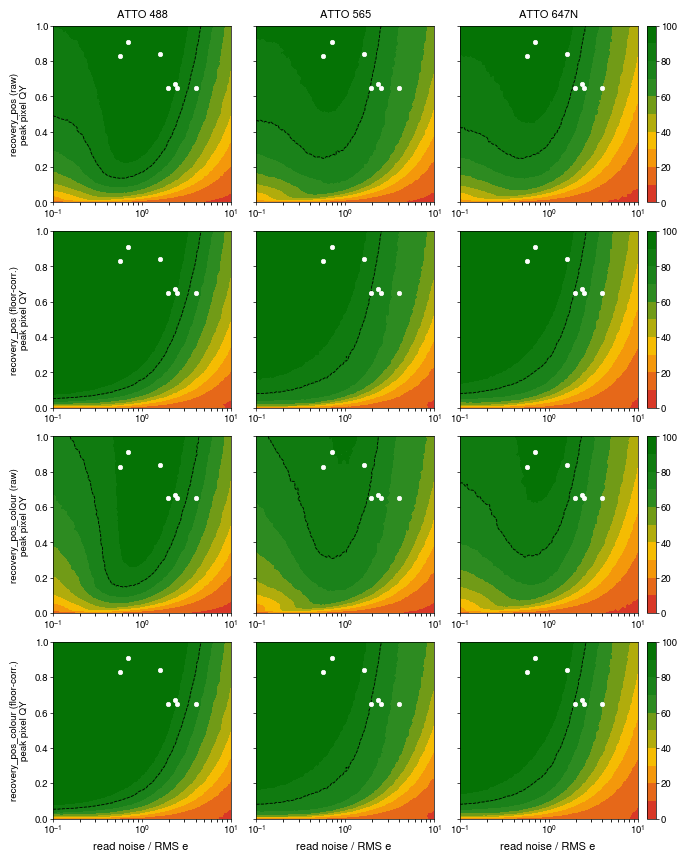

In [12]:
row_specs = [
    ('recovery_pos', yield_surf, 'recovery_pos (raw)'),
    ('recovery_pos', yield_surf_floorcorr, 'recovery_pos (floor-corr.)'),
    ('recovery_pos_colour', yield_surf, 'recovery_pos_colour (raw)'),
    ('recovery_pos_colour', yield_surf_floorcorr, 'recovery_pos_colour (floor-corr.)'),
]

fig, axs = plotter.two_column_plot(nrows=len(row_specs), ncols=len(dyes), width=6.75, height=8.5)

for row, (kind, surf, label) in enumerate(row_specs):
    for col, dye in enumerate(dyes):
        ax = axs[row, col]
        data = surf[dye][kind] * 100
        image = ax.contourf(
            read_noise_space, peak_qy_space, data,
            levels=fill_levels, cmap=cmap_yield, vmin=0, vmax=100, antialiased=False,
        )
        ax.contour(read_noise_space, peak_qy_space, data, levels=[80], colors='k', linewidths=0.6, linestyles='--')
        ax.set_xscale('log')
        ax.grid(False)
        ax.set_xlim([read_noise_space[0], read_noise_space[-1]])
        ax.set_ylim([0.0, 1])
        ax.tick_params(labelsize=7)
        if row == len(row_specs) - 1:
            ax.set_xlabel('read noise / RMS e⁻', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'{label}\npeak pixel QY', fontsize=7)
        else:
            ax.set_yticklabels('')
        if row == 0:
            ax.set_title(dye, fontsize=8)
        if col == len(dyes) - 1:
            cbar = plt.colorbar(image, ax=ax, pad=0.01, cmap=cmap_yield)
            cbar.set_ticks([0, 20, 40, 60, 80, 100])
        # SVG-only artefact: contourf bands paint no edge by default, so
        # antialiased=False alone still leaves a thin seam between adjacent bands in
        # vector output (invisible in matplotlib's own PNG export, but real in an SVG
        # viewer -- confirmed by rasterising with Inkscape's renderer). Painting each
        # band's edge in its own fill colour closes the seam; a generic
        # `for c in ax.collections: c.set_linewidth(0.1)` also touches the 80% contour
        # line above (it lives in ax.collections too), flattening its width --
        # targeting `image` specifically avoids that.
        image.set_edgecolor('face')
        image.set_linewidth(0.3)
        ax.scatter(
            camera_data['RMS'], camera_data['PeakQY'],
            s=10, lw=0.5, facecolor='white', edgecolors='white', zorder=5,
        )

plt.savefig('Fig_1c_floorcorr_comparison.svg', dpi=600, format='svg')
plt.show()